# Exercício:

## 01 – Importe o .csv utilizado no exercício 1 da aula 13 e instancie um objeto da classe DataFrame. Busque no GenBank do NCBI, a sequência aminoacídica referente à cada gene, baixe o arquivo FASTA, e importe para o Python. Instancie um objeto da classe DataFrame onde as linhas serão os genes e as colunas, a sigla, o código de referência e a sequência aminoacídica.

In [2]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as st
from Bio import Entrez

In [3]:
!pip install biopython

You should consider upgrading via the 'C:\Users\bianc\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [4]:
df_genes=pd.read_csv('df_4_8_7lista6.csv', index_col="Unnamed: 0")
df_genes.head()

,num_caract,primeiros_2_caract,quant_a,tem_hu
GAB2,4,GA,1,False
GRB2,4,GR,0,False
LYN,3,LY,0,False
PTGS1,5,PT,0,False
FGFR3,5,FG,0,False


In [5]:
df_genes['id_entrez'] = [
    "NM_080491.3",
    "NM_002086.5",
    "NM_002350.4",
    "NM_000962.4",
    "NM_000142.5",
]

df_genes['id_protein'] = [
    'NP_536739.1',
    "NP_002077.1",
    "NP_002341.1",
    "NP_000953.2",
    "NP_000133.1",
]
df_genes

,num_caract,primeiros_2_caract,quant_a,tem_hu,id_entrez,id_protein
GAB2,4,GA,1,False,NM_080491.3,NP_536739.1
GRB2,4,GR,0,False,NM_002086.5,NP_002077.1
LYN,3,LY,0,False,NM_002350.4,NP_002341.1
PTGS1,5,PT,0,False,NM_000962.4,NP_000953.2
FGFR3,5,FG,0,False,NM_000142.5,NP_000133.1


In [6]:
def salvar_fasta_gene(id_protein: str, nome_gene: str) -> None:
    '''
        Salva a sequência de um gene em formato FASTA.
            Args:
                id_protein (str): ID do gene no GenBank.
                nome_gene (str): Nome do gene para salvar o arquivo.
            Returns:
                None
    '''
    # Necessário informar seu email
    Entrez.email = "bianca.nkusma@gmail.com"

    # Busca a sequência (ex: um ID do GenBank) > acesso remoto que precisa abrir e fechar
    handle = Entrez.efetch(db="protein", id=id_protein, rettype="fasta", retmode="text")
    record = handle.read()
    handle.close()

    # Salva o arquivo
    with open(f"./{nome_gene}.fasta", "w") as f:
        fasta = f.write(record)
    
    return None

In [7]:
for index in df_genes.index:
    id_gene = df_genes.loc[index, "id_protein"]
    nome_gene = index 
    salvar_fasta_gene(nome_gene=nome_gene, id_protein=id_gene)
    time.sleep(10)  # Para evitar sobrecarga no servidor do NCBI
    print(nome_gene, id_gene)

GAB2 NP_536739.1
GRB2 NP_002077.1
LYN NP_002341.1
PTGS1 NP_000953.2
FGFR3 NP_000133.1


In [8]:
descr_gene = {}
for gene in df_genes.index:
    caminho = f"./{gene}.fasta"
    with open(caminho, 'r') as file:
        data = file.read()
        data = data.split('\n')
        cod = data[0].split(" ")[0]
        seq = ''.join(data[1:-2])
        descr_gene[gene] = {"gene": gene, "cod": cod, "seq": seq}
descr_gene_df = pd.DataFrame.from_dict(descr_gene, orient='index')
descr_gene_df.head()

,gene,cod,seq
GAB2,GAB2,>NP_536739.1,MSGGGDVVCTGWLRKSPPEKKLRRYAWKKRWFILRSGRMSGDPDVL...
GRB2,GRB2,>NP_002077.1,MEAIAKYDFKATADDELSFKRGDILKVLNEECDQNWYKAELNGKDG...
LYN,LYN,>NP_002341.1,MGCIKSKGKDSLSDDGVDLKTQPVRNTERTIYVRDPTSNKQQRPVP...
PTGS1,PTGS1,>NP_000953.2,MSRSLLLWFLLFLLLLPPLPVLLADPGAPTPVNPCCYYPCQHQGIC...
FGFR3,FGFR3,>NP_000133.1,MGAPACALALCVAVAIVAGASSESLGTEQRVVGRAAEVPGPEPGQQ...


## 02 – Importe o .csv as informações dos aminoácidos e instancie um objeto da classe DataFrame. Obtenha a frequência absoluta de cada um dos aminoácidos para cada um dos genes. Instancie um objeto da classe DataFrame com as informações.

In [9]:
from collections import Counter
aminoacidos = list("ACDEFGHIKLMNPQRSTVWY")
def contar_aminoacidos(seq):
    contagem = Counter(seq)
    return {aa: contagem.get(aa, 0) for aa in aminoacidos}

In [10]:
df_counts = descr_gene_df.copy()

# conta aminoácidos
df_counts_amino = df_counts['seq'].apply(contar_aminoacidos)

# transforma em DataFrame
df_amino = pd.DataFrame(df_counts_amino.tolist())

# adiciona o nome do gene
df_amino.index = descr_gene_df['gene']

df_amino

,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
gene,,,,,,,,,,,,,,,,,,,,
GAB2,38,9,36,35,21,39,18,19,33,43,15,34,61,30,43,96,47,33,7,19
GRB2,12,2,18,14,17,15,6,9,16,14,5,13,11,11,12,11,5,14,5,7
LYN,31,8,34,39,20,33,7,32,46,43,13,15,28,21,26,29,26,28,9,24
PTGS1,25,13,24,36,39,45,18,25,25,74,18,19,46,27,33,33,30,32,10,27
FGFR3,66,17,47,53,24,68,20,22,37,80,17,22,56,26,44,61,43,71,11,21


In [11]:
df_amino.to_csv('df_amino15.csv')

## 03 – Qual é o número de Valinas presentes em cada um dos genes? Qual o gene tem o maior número?

In [12]:
print(df_amino.loc[:,'V'])
print(f"Gene com mais valinas: {df_amino['V'].idxmax()}, com quantidade de valinas = {df_amino['V'].max()}")

gene
GAB2     33
GRB2     14
LYN      28
PTGS1    32
FGFR3    71
Name: V, dtype: int64
Gene com mais valinas: FGFR3, com quantidade de valinas = 71


## 04 – Qual a média, a mediana e a moda da frequência absoluta de Serina presente nos genes?

In [13]:
print(f"Média = {st.mean(df_amino.loc[:,'S'])}")
print(f"Mediana = {st.median(df_amino.loc[:,'S'])}")
print(f"Moda = {st.mode(df_amino.loc[:,'S'])}")

Média = 46
Mediana = 33
Moda = 96


## 05 – Gere um histograma, contendo a média e a mediana, com o número de Serinas por gene.

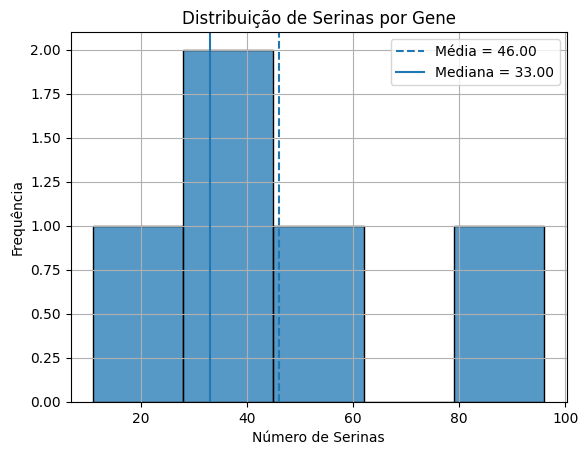

In [14]:
media = df_amino['S'].mean()
mediana = df_amino['S'].median()

plt.figure()
sns.histplot(df_amino['S'], bins=5, kde=False)

plt.axvline(media, linestyle='--', label=f'Média = {media:.2f}')
plt.axvline(mediana, linestyle='-', label=f'Mediana = {mediana:.2f}')

plt.title('Distribuição de Serinas por Gene')
plt.xlabel('Número de Serinas')
plt.ylabel('Frequência')
plt.legend()
plt.grid()

plt.show()

## 06 – Defina uma função que receba o nome de um aa qualquer e retorne o mesmo resultado do exercício anterior.

In [15]:
def gerar_hist(coluna, nome_variavel=None):
    
    # se não passar nome, tenta pegar automaticamente
    if nome_variavel is None:
        nome_variavel = coluna.name
    
    media = coluna.mean()
    mediana = coluna.median()

    plt.figure()
    sns.histplot(coluna, bins=5, kde=False)

    plt.axvline(media, linestyle='--', label=f'Média = {media:.2f}')
    plt.axvline(mediana, linestyle='-', label=f'Mediana = {mediana:.2f}')

    plt.title(f'Distribuição de {nome_variavel}')
    plt.xlabel(nome_variavel)
    plt.ylabel('Frequência')
    plt.legend()
    plt.grid()

    return plt.show()

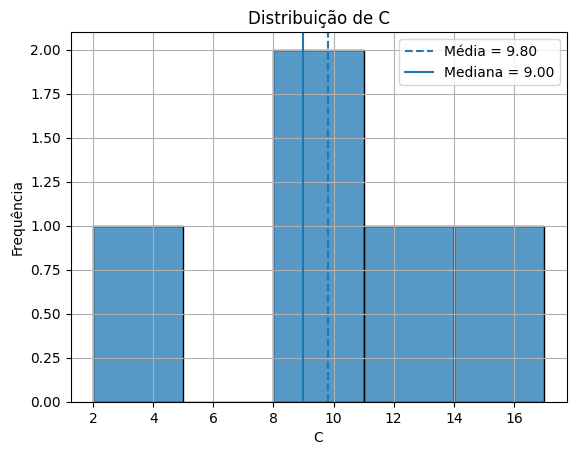

In [16]:
gerar_hist(df_amino['C'])

## 07 – Retorne os gráficos dos aa Glutamina, Glicina, Lisina e Valina. Qual possuí menor diferença entre média e mediana?

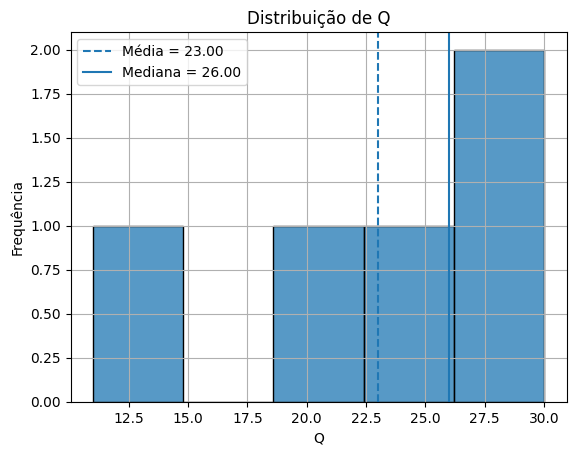

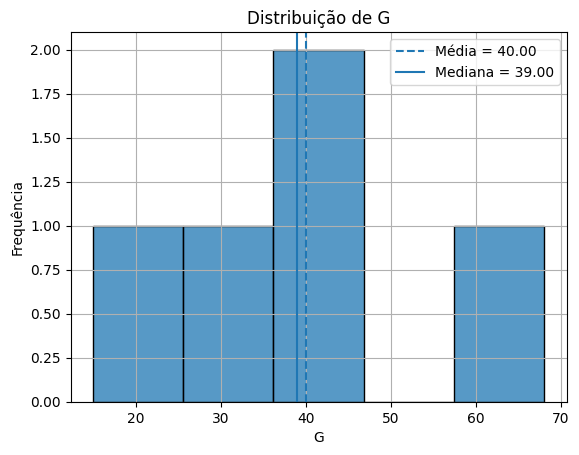

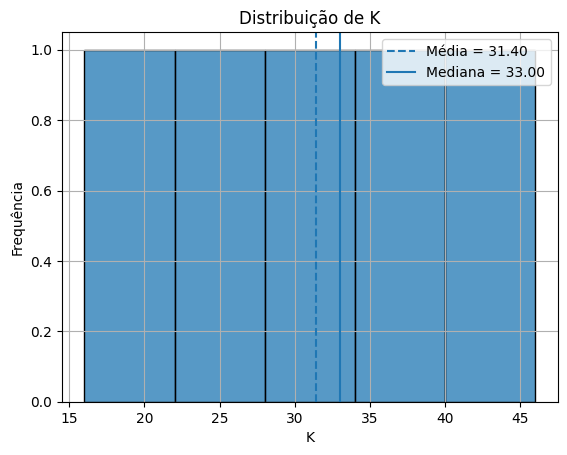

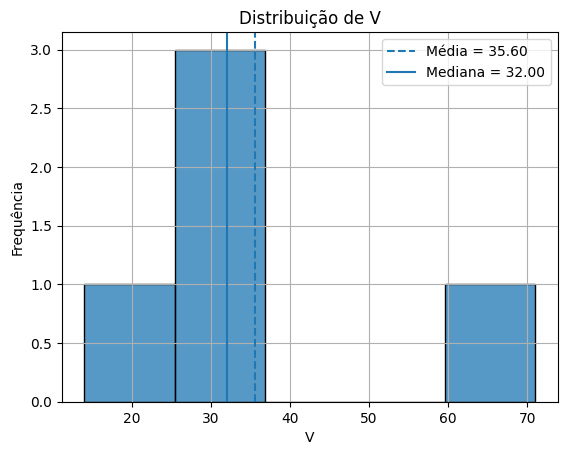

In [17]:
gerar_hist(df_amino['Q'])
gerar_hist(df_amino['G'])
gerar_hist(df_amino['K'])
gerar_hist(df_amino['V'])

In [18]:
#Para glicina tem-se a menor diferença entre media e mediana
def menor_dif_m(df, colunas):
    
    resultados = {}
    
    for col in colunas:
        media = df[col].mean()
        mediana = df[col].median()
        diferenca = abs(media - mediana)
        
        resultados[col] = diferenca
    
    # encontrar a menor diferença
    melhor_coluna = min(resultados, key=resultados.get)
    
    return f"Coluna com a menor diferença: {melhor_coluna}", resultados

menor_dif_m(df_amino,['Q','G','K','V'])

('Coluna com a menor diferença: G',
 {'Q': np.float64(3.0),
  'G': np.float64(1.0),
  'K': np.float64(1.6000000000000014),
  'V': np.float64(3.6000000000000014)})

## 08 – Dentre os três primeiros genes, qual é a média e a mediana de Cisteína?

In [19]:
print(f"média= ",{st.mean(df_amino.iloc[:3]['C'])})
print(f"mediana= ",{st.median(df_amino.iloc[:3]['C'])})

média=  {6.333333333333333}
mediana=  {8}


## 09 – Analisando o valor médio de aa em cada um dos genes, qual seria o maior gene (maior número médio de aa)?

In [20]:
maior_gene = df_amino.mean(axis=1).idxmax()
maior_valor = df_amino.mean(axis=1).max()

print(f"Gene com maior média de aminoácidos: {maior_gene} ({maior_valor:.2f})")

Gene com maior média de aminoácidos: FGFR3 (40.30)


## 10 – Olhando o valor médio de aa em cada um dos genes, qual seria o menor gene (menor número médio de aa)?

In [21]:
menor_gene = df_amino.mean(axis=1).idxmin()
menor_valor = df_amino.mean(axis=1).min()

print(f"Gene com menor média de aminoácidos: {menor_gene} ({menor_valor:.2f})")

Gene com menor média de aminoácidos: GRB2 (10.85)
